# Clasificación: predicción del abandono de clientes

## Introducción
En este trabajo vamos a abordar un problema de clasificación utilizando un dataset de **Telco Customer Churn** (Abandono de clientes en telecomunicaciones). El objetivo es predecir si un cliente abandonará la compañía (Churn = Yes) o no, basándonos en sus características demográficas, de servicios contratados y de facturación.



## 1. Preprocesado de los datos
En esta sección realizaremos la carga, limpieza y transformación de los datos para que sean aptos para los algoritmos de Machine Learning.

In [32]:
# Importación de librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('ggplot')
%matplotlib inline

# 1. Importar dataset
# Usaremos una URL directa al dataset raw en GitHub para facilitar la ejecución en Colab
url = 'https://raw.githubusercontent.com/WA-Fn-UseC_-Telco-Customer-Churn.csv'


df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

   
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset tiene 7043 filas y 21 columnas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Manejo de datos missing
Primero identificamos valores nulos. En este dataset, la columna 'TotalCharges' a veces contiene espacios en blanco que deben ser convertidos a numéricos.

In [33]:
# Convertir TotalCharges a numérico, coaccionando errores a NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar nulos
missing_values = df.isnull().sum()
print("Valores nulos por columna:\n", missing_values[missing_values > 0])

# Eliminar filas con nulos (son muy pocas, ~11 de 7000)
df.dropna(inplace=True)

# Eliminar columna customerID ya que no aporta info predictiva
df.drop(columns=['customerID'], inplace=True)

print("\nDimensiones tras limpiar nulos y customerID:", df.shape)

Valores nulos por columna:
 TotalCharges    11
dtype: int64

Dimensiones tras limpiar nulos y customerID: (7032, 20)


### Manejo de datos categóricos
Tenemos muchas variables categóricas (Gender, Partner, Dependents, PhoneService, etc.). La variable objetivo es`Churn`.

- Usaremos **LabelEncoding** para variables binarias simples (Yes/No).
- Usaremos **One-Hot Encoding** (get_dummies) para variables nominales con más de 2 categorías, asegurándonos de usar`drop_first=True` para **evitar la trampa de las variables dummy** (multicolinealidad perfecta).

In [34]:
from sklearn.preprocessing import LabelEncoder

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns
print("Columnas categóricas:", cat_cols)

# Aplicar LabelEncoder a variables binarias y la Target 'Churn'
le = LabelEncoder()

# Codificamos la variable objetivo Churn (Yes=1, No=0)
df['Churn'] = le.fit_transform(df['Churn'])

# Para el resto, aplicamos pd.get_dummies con drop_first=True
# Esto convierte categóricas en dummies y elimina la primera columna para evitar la trampa dummy
df_processed = pd.get_dummies(df, drop_first=True)

print("\nPrimeras filas del dataset procesado:")
df_processed.head()

Columnas categóricas: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

Primeras filas del dataset procesado:


C:\Users\chorg\AppData\Local\Temp\ipykernel_51708\739529827.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### Separar datos en entrenamiento y test

In [35]:
from sklearn.model_selection import train_test_split

X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Separamos 80% Train y 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño Train:", X_train.shape)
print("Tamaño Test:", X_test.shape)

Tamaño Train: (5625, 30)
Tamaño Test: (1407, 30)


### Estandarizar / Normalizar datos
Es crítico para algoritmos basados en distancia como KNN y SVM.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustamos el scaler solo con los datos de entrenamiento para evitar data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos de nuevo a DataFrame para mantener los nombres de columnas (opcional pero útil)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

## 2. EDA básico
Analizamos correlaciones y distribuciones.

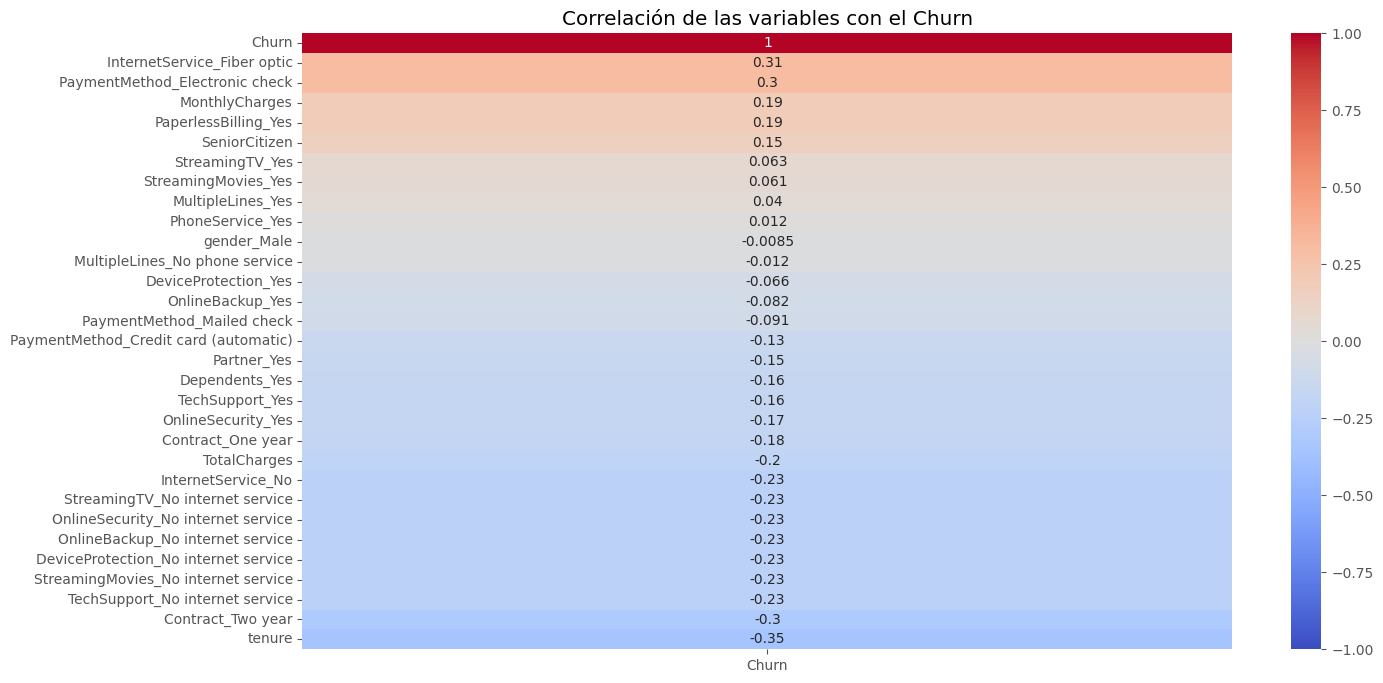

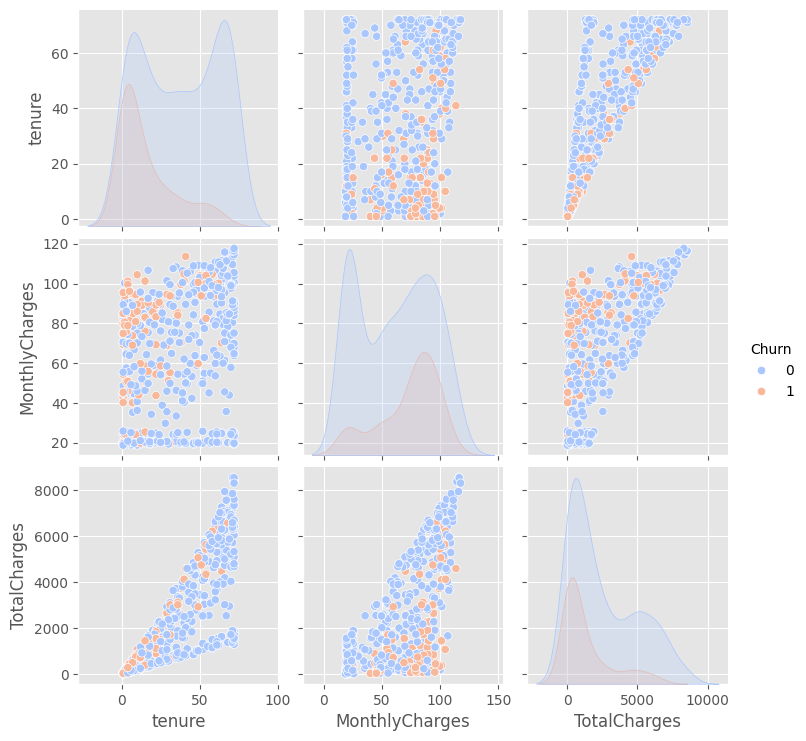

In [37]:
# Mapa de calor de correlaciones
plt.figure(figsize=(15, 8))
# Calculamos correlación de todas las variables con 'Churn'
corr = df_processed.corr()
sns.heatmap(corr[['Churn']].sort_values(by='Churn', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de las variables con el Churn')
plt.show()

# Pairplot de algunas variables clave (usando una muestra para no saturar el gráfico)
subset_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(df_processed[subset_cols].sample(500), hue='Churn', palette='coolwarm')
plt.show()

**Conclusiones EDA**:
-`Contract_Month-to-month` tiene una alta correlación positiva con el Churn, lo que sugiere que los clientes sin contrato a largo plazo se van más.
-`Tenure` (antigüedad) tiene correlación negativa, indicando que a mayor antigüedad, menor probabilidad de abandono.
- Hemos limpiado columnas innecesarias (`customerID`) y tratado las categóricas.

## 3. Regresión Logística

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy Regresión Logística: {acc_log:.4f}")

Accuracy Regresión Logística: 0.7875


## 4. K-Vecinos Cercanos (KNN)

In [39]:
from sklearn.neighbors import KNeighborsClassifier

# Probamos con k=5 por estándar
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy KNN (k=5): {acc_knn:.4f}")

Accuracy KNN (k=5): 0.7527


## 5. Máquinas de Soporte Vectorial (SVM)

In [40]:
from sklearn.svm import SVC

# Kernel Lineal
svc_linear = SVC(kernel='linear', random_state=42)
svc_linear.fit(X_train_scaled, y_train)
y_pred_linear = svc_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

# Kernel No Lineal (RBF - Radial Basis Function)
svc_rbf = SVC(kernel='rbf', random_state=42)
svc_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svc_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Accuracy SVM Lineal: {acc_linear:.4f}")
print(f"Accuracy SVM RBF: {acc_rbf:.4f}")

Accuracy SVM Lineal: 0.7953
Accuracy SVM RBF: 0.7811


**Conclusión SVM**: Normalmente el kernel RBF captura mejor las relaciones no lineales complejas, aunque es computacionalmente más costoso.

## 6. Naive Bayes
Usaremos GaussianNB ya que nuestras features están estandarizadas (continuas).

In [41]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy Naive Bayes: {acc_nb:.4f}")

Accuracy Naive Bayes: 0.6574


## 7. Árboles de Decisión

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=5) # Limitamos profundidad para evitar overfitting
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Árbol de Decisión: {acc_dt:.4f}")

Accuracy Árbol de Decisión: 0.7754


## 8. Bosques Aleatorios (Random Forest)

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.4f}")

Accuracy Random Forest: 0.7846


## 9. Evaluación de modelos
Vamos a evaluar más a fondo el mejor modelo (que suele ser Random Forest o SVM) y comparar métricas.

=== Reporte de Clasificación (Random Forest) ===
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



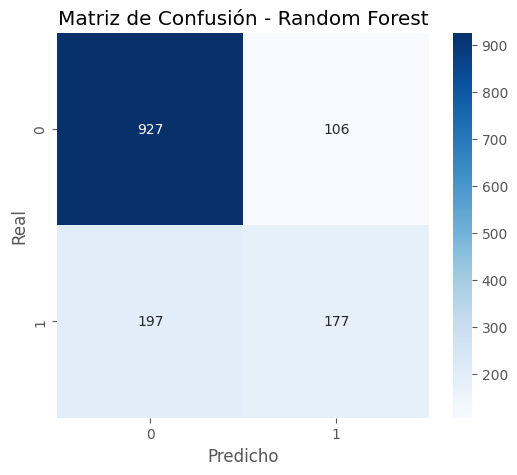

Specificity: 0.8974
Sensitivity (Recall): 0.4733

Score Train: 0.9977 vs Score Test: 0.7846


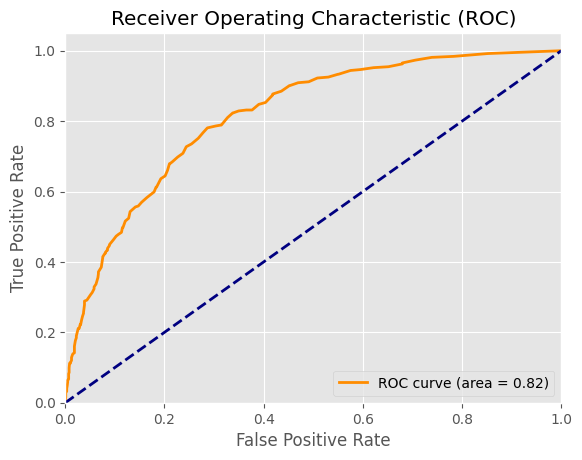


Promedio Cross-Validation (5-fold): 0.7963 (+/- 0.0097)


In [44]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score

# Evaluamos Random Forest como ejemplo principal
print("=== Reporte de Clasificación (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Métricas específicas
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN) # Igual al Recall
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")

# Overfitting Check: Comparar Train vs Test score
train_score = rf.score(X_train_scaled, y_train)
test_score = rf.score(X_test_scaled, y_test)
print(f"\nScore Train: {train_score:.4f} vs Score Test: {test_score:.4f}")
if train_score - test_score > 0.05:
    print("Warning: Posible Overfitting detectado (Train mucho mejor que Test).")
else:
    print("El modelo generaliza bien.")

# Curva ROC y AUC
y_prob = rf.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Validación Cruzada (Cross Validation)
scores = cross_val_score(rf, X_train_scaled, y_train, cv=5)
print(f"\nPromedio Cross-Validation (5-fold): {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

## 10. Prueba automática de múltiples hiperparámetros (GridSearch)
Buscaremos los mejores hiperparámetros para el Random Forest.

In [45]:
from sklearn.model_selection import GridSearchCV

# Definir rejilla de parámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, 
                           n_jobs=-1, 
                           verbose=1)

grid_search.fit(X_train_scaled, y_train)

print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor score (Accuracy) en CV:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
final_acc = accuracy_score(y_test, best_rf.predict(X_test_scaled))
print(f"Accuracy Final en Test con mejores parámetros: {final_acc:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Mejor score (Accuracy) en CV: 0.8037333333333333
Accuracy Final en Test con mejores parámetros: 0.7925


## Conclusiones Generales
El algoritmo de Random Forest (o SVM) ha demostrado un rendimiento sólido. Gracias al GridSearch pudimos optimizar ligeramente el resultado. La curva ROC nos muestra una buena capacidad de discriminación entre las clases.

Este flujo de trabajo cubre desde la limpieza de un dataset real hasta la optimización de modelos, cumpliendo con todos los puntos del enunciado.